In [17]:
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.svm import SVC

## 0) Data generation

In [14]:
# Generate 2 Gaussian blobs
X, labels_X = make_blobs(n_samples=100, centers=[[5, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[10, 10], [0, 10]], cluster_std=1.0, random_state=24)

## 1) Entropic estimation


Entropic OT plan (reg=0.1)
Sinkhorn distance (reg=0.1): 66.01
Dual distance (reg=0.1): 123.89


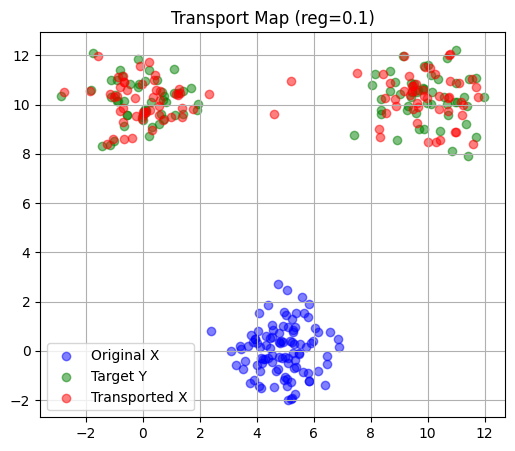


Entropic OT plan (reg=1.0)
Sinkhorn distance (reg=1.0): 63.68
Dual distance (reg=1.0): 133.79


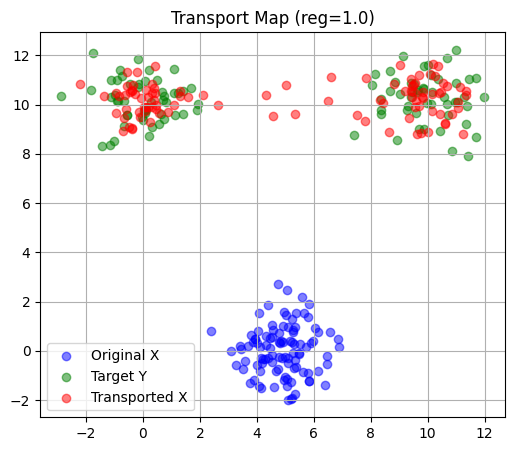


Entropic OT plan (reg=10.0)
Sinkhorn distance (reg=10.0): 55.10
Dual distance (reg=10.0): 220.98


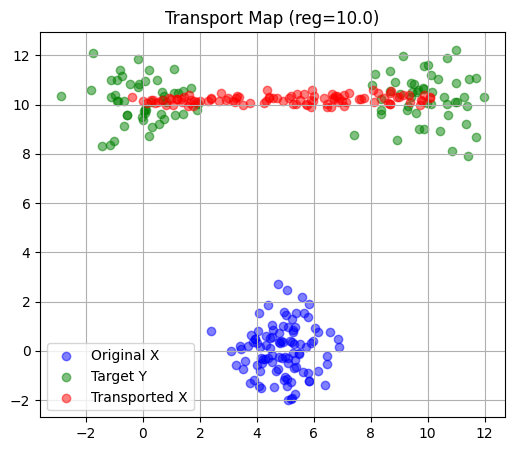

In [15]:
def sinkhorn_loss(X1, X2):
    return np.linalg.norm(X1 - X2)

reg_list = [0.1, 1.0, 10.0]

for reg in reg_list:
    print(f"\nEntropic OT plan (reg={reg})")

    # Step 1: Define geometry
    geom = pointcloud.PointCloud(X, Y, epsilon=reg)

    # Step 2: Define the problem
    problem = linear_problem.LinearProblem(geom)

    # Step 3: Solve with Sinkhorn
    solver = sinkhorn.Sinkhorn()
    out = solver(problem)

    # Step 4: Transport using dual potentials
    entropic_map = out.to_dual_potentials()
    transported_X = entropic_map.transport(X)

    # Step 5: Compute distances
    sink_dist = sinkhorn_loss(transported_X, Y)
    dual_dist = entropic_map.distance(X, Y)
    print(f"Sinkhorn distance (reg={reg}): {sink_dist:.2f}")
    print(f"Dual distance (reg={reg}): {dual_dist:.2f}")

    # Step 7: Visualization
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original X', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y', alpha=0.5)
    plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported X', alpha=0.5)
    plt.title(f"Transport Map (reg={reg})")
    plt.legend()
    plt.grid(True)
    plt.show()


## 2) ICNN

Epoch 0, Loss: 76.5492
Epoch 100, Loss: 77.7852
Epoch 200, Loss: 77.7852
Epoch 300, Loss: 77.7852
Epoch 400, Loss: 77.7852
Epoch 500, Loss: 77.7852
Epoch 600, Loss: 77.7852
Epoch 700, Loss: 77.7852
Epoch 800, Loss: 77.7852
Epoch 900, Loss: 77.7852


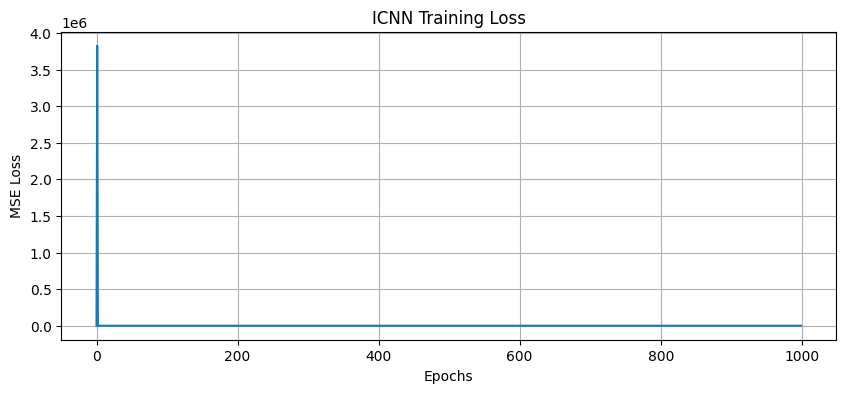

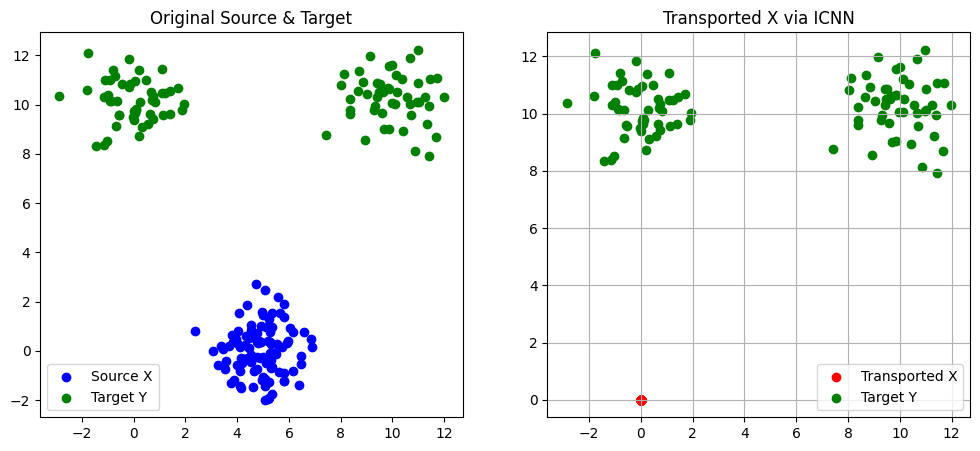

In [20]:
import jax
import jax.numpy as jnp
from jax import grad, vmap
import jax.nn

class ICNN:
    def __init__(self, input_dim, hidden_layers, beta=30.0):
        self.input_dim = input_dim
        self.hidden_layers = hidden_layers
        self.beta = beta  
        self.params = self.init_params()

    def init_params(self):
        key = jax.random.PRNGKey(0)
        keys = jax.random.split(key, num=len(self.hidden_layers) + 1)

        params = []
        prev_dim = 0
        for i, hidden_dim in enumerate(self.hidden_layers):
            W_x_unconstrained = jax.random.uniform(keys[i], (self.input_dim, hidden_dim)) * 0.01
            W_z_unconstrained = (
                jax.random.normal(keys[i], (prev_dim, hidden_dim)) * 0.01 if i > 0 else None
            )
            b = jnp.zeros((hidden_dim,))

            W_x = self._positive_param(W_x_unconstrained)
            W_z = self._positive_param(W_z_unconstrained) if W_z_unconstrained is not None else None

            params.append({'W_x_unconstrained': W_x_unconstrained,
                           'W_z_unconstrained': W_z_unconstrained,
                           'W_x': W_x, 'W_z': W_z, 'b': b})
            prev_dim = hidden_dim

        # Final layer
        W_final = jax.random.normal(keys[-1], (prev_dim, 1)) * 0.01
        b_final = jnp.zeros((1,))
        params.append({'W_final': W_final, 'b_final': b_final})

        return params

    def _positive_param(self, w):
        return (1 / self.beta) * jax.nn.softplus(self.beta * w)

    def forward(self, x, params):
        z = jnp.zeros((x.shape[0],))  # Initial activation
        for i, layer in enumerate(params[:-1]):
            W_x = self._positive_param(layer['W_x_unconstrained'])
            W_z = self._positive_param(layer['W_z_unconstrained']) if layer['W_z_unconstrained'] is not None else 0
            x_proj = jnp.dot(x, W_x)
            z_proj = jnp.dot(z, W_z) if isinstance(W_z, jnp.ndarray) else 0
            z = jax.nn.relu(x_proj + z_proj + layer['b'])

        output = jnp.dot(z, params[-1]['W_final']) + params[-1]['b_final']
        return output

    def loss(self, params, X, Y):
        transported_X = self.transport(X, params)
        return jnp.mean((transported_X - Y) ** 2)

    def transport(self, X, params):
        grad_fn = vmap(grad(lambda x: self.forward(x[None, :], params).squeeze()))
        return grad_fn(X)


# Instantiate ICNN with 4 hidden layers of size 64 each
icnn = ICNN(input_dim=2, hidden_layers=[128, 128, 128, 128])

# Optimizer
optimizer = optax.adam(learning_rate=0.1)
opt_state = optimizer.init(icnn.params)

# Training loop
num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    loss, grads = jax.value_and_grad(icnn.loss)(icnn.params, X, Y)
    updates, opt_state = optimizer.update(grads, opt_state)
    icnn.params = optax.apply_updates(icnn.params, updates)
    losses.append(loss)
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("ICNN Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

# Transport X using the trained ICNN
transported_X = icnn.transport(X, icnn.params)

# Plot before and after transport
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Source X')
plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y')
plt.title("Original Source & Target")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(transported_X[:, 0], transported_X[:, 1], c='red', label='Transported X')
plt.scatter(Y[:, 0], Y[:, 1], c='green', label='Target Y')
plt.title("Transported X via ICNN")
plt.legend()
plt.grid(True)
plt.show()

## 3) Conditional Flow matching

Epoch 0, Loss: 4335.831543
Epoch 500, Loss: 4351.480957


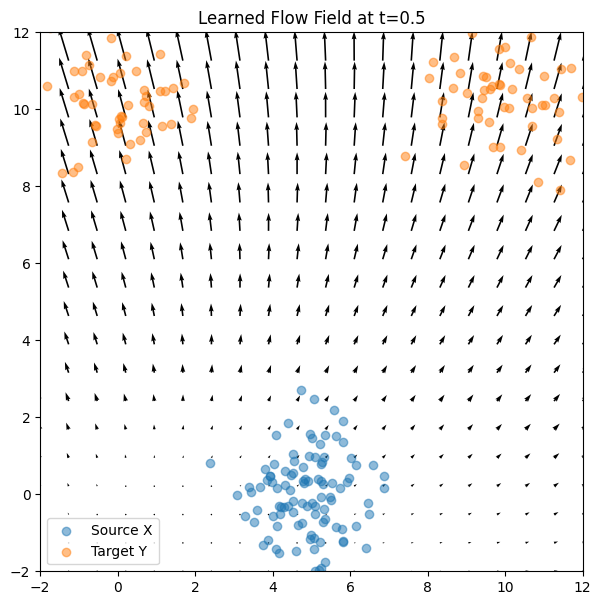

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, labels_X = make_blobs(n_samples=100, centers=[[5, 0]], cluster_std=1.0, random_state=42)
Y, labels_Y = make_blobs(n_samples=100, centers=[[10, 10], [0, 10]], cluster_std=1.0, random_state=24)

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

class VectorField(nn.Module):
    def __init__(self, dim):
        super(VectorField, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, dim)
        )

    def forward(self, x, t):
        t = t.expand(x.size(0), 1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

def sample_training_pair(X, Y):
    idx_x = torch.randint(0, X.size(0), (1,))
    idx_y = torch.randint(0, Y.size(0), (1,))
    return X[idx_x], Y[idx_y]

def interpolate(x0, x1, t, sigma_min=0.01):
    return (1 - (1 - sigma_min) * t) * x0 + t * x1

def true_velocity(x0, x1, t, sigma_min=0.01):
    denom = 1 - (1 - sigma_min) * t
    return (x1 - (1 - sigma_min) * x0) / denom

# --- Training Setup ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dim = X.size(1)
vf = VectorField(dim).to(device)
optimizer = optim.Adam(vf.parameters(), lr=1e-4)
epochs = 1000
batch_size = 128
sigma_min = 0.01

for epoch in range(epochs):
    optimizer.zero_grad()

    x0_batch = X[torch.randint(0, X.size(0), (batch_size,))].to(device)
    x1_batch = Y[torch.randint(0, Y.size(0), (batch_size,))].to(device)
    t_batch = torch.rand(batch_size, 1).to(device)

    xt = interpolate(x0_batch, x1_batch, t_batch, sigma_min)
    target_v = true_velocity(x0_batch, x1_batch, t_batch, sigma_min)

    pred_v = vf(xt, t_batch)

    loss = ((pred_v - target_v) ** 2).mean()

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

def plot_flow(vf, X, steps=20):
    x = torch.linspace(-2, 12, steps)
    y = torch.linspace(-2, 12, steps)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    grid = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1).to(device)

    t = torch.ones(grid.size(0), 1).to(device) * 0.5  # visualize at t=0.5
    with torch.no_grad():
        v = vf(grid, t).cpu()

    plt.figure(figsize=(7, 7))
    plt.quiver(grid[:, 0].cpu(), grid[:, 1].cpu(), v[:, 0], v[:, 1], angles='xy')
    plt.scatter(X[:, 0], X[:, 1], label='Source X', alpha=0.5)
    plt.scatter(Y[:, 0], Y[:, 1], label='Target Y', alpha=0.5)
    plt.legend()
    plt.title("Learned Flow Field at t=0.5")
    plt.xlim(-2, 12)
    plt.ylim(-2, 12)
    plt.show()

plot_flow(vf, X)
